<a href="https://colab.research.google.com/github/damionhu-star/467/blob/main/ee443_hw1_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

version 1 (Last Updated 2026/03/31)

# Problem 1: Principal Component Analysis (25\%)



### Introduction

Principal component analysis (PCA) is a technique that transforms high-dimension data into lower dimensions while retaining as much information as possible.

We do dimensionality reduction to convert the high $d$-dimensional dataset into $k$-dimensional data where $k<d$. It's possible for data to have a significantly larger variance on one axis compared to another. Typically, a higher variance suggests more information is present in that direction. Consequently, we can disregard dimensions with less variance since they contain less information.

In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

### Dataset

ORL Face Data The face data set used in this question is the ORL database of faces. Each face is a 56x46 array of pixels that has been flattened into a 1D-vector of length 2576. (Note: prior to plotting any images, you must reshape the image back into a 2D array of dimensions 56x46. See the last cell in the Introduction section for an example of how to do this).


- `X_train.csv`: each of the 360 lines contains data for a 56 × 46 face image.
- `Y_train.csv`: each of the 360 lines contains the label for the corresponding line in X\_train.csv.
- `X_test.csv`: each of the 40 lines contains data for a 56 x 46 face image.
- `Y_test.csv`: labels for face images in X\_test.csv.

In [2]:
# Upload the data to your google drive from Canvas then mount to the folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Use the command `%ls` ([IPython built-in magic command](https://ipython.readthedocs.io/en/stable/interactive/magics.html)) to locate your folder.



In [3]:
folder_path = "drive/MyDrive/EE443_2026/hw1/"

%ls -l drive/MyDrive/EE443_2026/hw1/

total 18005
-rw------- 1 root root 18104992 Apr 14 20:41 'Copy of data_hw1.zip'
-rw------- 1 root root    41593 Apr 14 20:41 'Copy of ee443_hw1 (1).ipynb'
-rw------- 1 root root    52646 Apr 14 20:41 'Copy of ee443_hw1.ipynb'
-rw------- 1 root root   232021 Apr 14 20:41 'Copy of EE443_Spring_2026___Homework_1.pdf'
drwx------ 2 root root     4096 Mar 31 17:09  data_hw1/


In [4]:
!unzip drive/MyDrive/EE443_2026/HW1/data_hw1.zip -d drive/MyDrive/EE443_2026/hw1/

Archive:  drive/MyDrive/EE443_2026/HW1/data_hw1.zip
replace drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/X_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/X_test.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/X_train.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/Y_test.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/Y_train.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p2/mnist_test.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p2/mnist_train.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p4/hw1_p4_column_definitions.txt  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p4/hw1_p4_test_data.csv  
  inflating: drive/MyDrive/EE443_2026/hw1/data_hw1/data/p4/hw1_p4_train_data.csv  


In [5]:
folder_path = "drive/MyDrive/EE443_2026/hw1/data_hw1/"

In [6]:
def load_data(filename):
    data = []
    with open(filename, 'r') as f:
        lines = csv.reader(f, delimiter=',')
        for line in lines:
            data.append([float(x) for x in line])
    data = np.array(data)
    print(f'Loaded {filename} with {len(data)} samples (shape: {data.shape})')
    return data

def vis_data_2d(data):
    # visualize a 2d data as an image
    assert len(data.shape) == 2
    plt.figure(figsize=(4, 2))
    plt.imshow(data, cmap='gray')
    plt.axis('off')

In [7]:
x_train = load_data(folder_path + "data/p1/X_train.csv")
x_test = load_data(folder_path + "data/p1/X_test.csv")
y_train = load_data(folder_path + "data/p1/Y_train.csv")
y_test = load_data(folder_path + "data/p1/Y_test.csv")

Loaded drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/X_train.csv with 360 samples (shape: (360, 2576))
Loaded drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/X_test.csv with 40 samples (shape: (40, 2576))
Loaded drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/Y_train.csv with 360 samples (shape: (360, 1))
Loaded drive/MyDrive/EE443_2026/hw1/data_hw1/data/p1/Y_test.csv with 40 samples (shape: (40, 1))


ID: 1


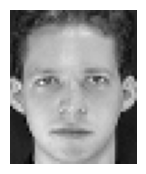

In [8]:
# Visualize an image
first_data_sample_in_train_img = x_train[0].reshape((56, 46))
first_data_sample_in_train_label = y_train[0][0]
vis_data_2d(first_data_sample_in_train_img)
print(f"ID: {int(first_data_sample_in_train_label)}")

### Principal Component Analysis

1-(a). Implementation of `my_pca()`

1. (Data Standardization) Compute the mean face $\bar{x}$ of the 360 training faces, and subtract it from each training data point:

    \begin{align}
        \bar{x} = \frac{1}{N}\sum^{N}_{n=1} x_n
    \end{align}

2. (Covariance Matrix) Compute the covariance matrix $S$ using np.cov()::
    \begin{align}
        S = \frac{1}{N}\sum^{N}_{n=1} (x_n - \bar{x})(x_n - \bar{x})^T.
    \end{align}

3. (Eigen-Decomposition) Perform eigen-decomposition on $S$ using \texttt{np.linalg.eigh()} to obtain eigenvalues $\Lambda$ and eigenvectors $V$:
    \begin{align}
        S = V \cdot \Lambda \cdot V^T &= \begin{bmatrix}
                                        \vdots & \vdots & & \vdots \\
                                        v_1 & v_2 & \dots & v_d \\
                                        \vdots & \vdots & & \vdots \\
                                        \end{bmatrix}
                                        \begin{bmatrix}
                                        \lambda_1 & 0 & \dots & 0 \\
                                        0 & \lambda_2 & \dots & 0 \\
                                        \vdots & \vdots & \ddots & \vdots \\
                                        0 & 0 & \dots & \lambda_d
                                        \end{bmatrix}
                                        \begin{bmatrix}
                                        \dots & v_1 & \dots \\
                                        \dots & v_2 & \dots \\
                                        & \vdots &  \\
                                        \dots & v_d & \dots \\
                                        \end{bmatrix}\\
        &= \begin{bmatrix}
            \lambda_1 v_1 & \lambda_1 v_1 & \dots & \lambda_d v_d
        \end{bmatrix}
        \begin{bmatrix}
            v_1\\ v_2\\ \vdots \\v_d
        \end{bmatrix} \\
        &= \lambda_1 v_1 v_1^T + \lambda_2 v_2 v_2^T + \dots + \lambda_d v_d v_d^T
    \end{align}
where
    \begin{equation}
                \Lambda = diag(\lambda_1, \lambda_2, ...),
    \end{equation}
and the corresponding eigenvectors $v$ are in:
    \begin{equation}
                V = [v_1 | v_2 | ...].
    \end{equation}

4. (Sort the Principal Components) Sort eigenvalue-eigenvector pairs by the value of eigenvalue then Choose top-$k$ eigenvectors to form a reprojection matrix.

In [9]:
def my_pca(x):
    # 1. Data Standardization: Comput the mean of x_train
    # TODO
    x_mean = np.mean(x, axis=0)
    # TODO
    print(f"x_mean Shape: {x_mean.shape}") # should be a shape of (2576,) or (784,)
    # TODO subtract x_mean for each training data point
    x_norm = x - x_mean

    # 2. Covariance Matrix: Compute the covariance matrix
    # TODO
    covariance_matrix = np.cov(x_norm.T)
    # TODO
    print(f"Covariance Matrix Shape: {covariance_matrix.shape}") # should be a shape of (2576, 2576) or (784, 784)

    # 3. Eigen-Decomposition: Compute the eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    print(f"Eigenvalues Shape: {eigenvalues.shape}") # should be a shape of (2576,) or (784,)
    print(f"Eigenvectors Shape: {eigenvectors.shape}") # should be a shape of (2576, 2576) or (784, 784)

    # 4. Sort the eigenvalues in descending order
    # TODO
    sorted_eigenvalues = eigenvalues[::-1]
    sorted_eigenvectors = eigenvectors[:, ::-1]
    # TODO

    return x_mean, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors

def reproject(x, top_k_eigenvectors, x_mean):
    # TODO: calculate projection on mean-centered x
    x_reproject = (x - x_mean) @ top_k_eigenvectors
    # TODO
    return x_reproject

def reconstruct(x, top_k_eigenvectors, x_mean):
    # TODO
    x_reconstruct = x_mean + (x - x_mean) @ top_k_eigenvectors @ top_k_eigenvectors.T
    # TODO
    print(f"x_reconstruct Shape: {x_reconstruct.shape}")

    return x_reconstruct

In [10]:
# Run the PCA on x_train
x_mean, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors = my_pca(x_train)

x_mean Shape: (2576,)
Covariance Matrix Shape: (2576, 2576)
Eigenvalues Shape: (2576,)
Eigenvectors Shape: (2576, 2576)


1-(b). [3pts] Report the 5 largest eigenvalues and their cumulative explained variance ratio:

\begin{equation*}
    \text{CEVR}_k = \frac{\sum_{i=1}^k \lambda_i}{\sum_{i=1}^d \lambda_i}   
\end{equation*}

In [11]:
t = 5
print(sorted_eigenvalues[:t])

def get_CEVR(sorted_eigenvalues, k):
    # TODO
    sum_eigenvalues = np.sum(sorted_eigenvalues)
    top_k_sum_eigenvalues = np.sum(sorted_eigenvalues[:k])
    return top_k_sum_eigenvalues / sum_eigenvalues

print(get_CEVR(sorted_eigenvalues, t))

[718124.7403874  511371.79264177 276354.44752864 226580.92484444
 202114.8575661 ]
0.4846596333737486


1-(c). [3pts] Plot the mean face and the eigenfaces corresponding to the 5 largest eigenvalues as 56 × 46 images from 1-(a).

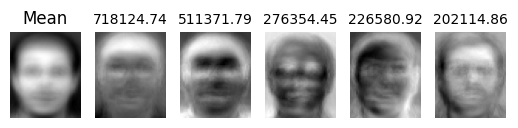

In [12]:
# TODO
mean_face = x_mean.reshape((56, 46))
top_k_eigenface = [sorted_eigenvectors[:, i].reshape((56, 46)) for i in range(5)]
top_k_eigenvalue = sorted_eigenvalues[:5]
# TODO

f, axarr = plt.subplots(1,6)

axarr[0].imshow(mean_face, cmap='gray')
axarr[0].set_title('Mean')
axarr[0].axis('off')

for i in range(5):
    axarr[i+1].imshow(top_k_eigenface[i], cmap='gray')
    axarr[i+1].set_title('{:.2f}'.format(top_k_eigenvalue[i]), fontsize=10)
    axarr[i+1].axis('off')

1-(d). [3pts] Take the first three rows in the train\_X.csv as input $x$. Reconstruct the face with the first $n=5, 20, 100, 200$ eigenfaces by:

\begin{equation}
    \hat x \approx \bar x + (x-\bar x) \cdot V_k \cdot V^T_k
\end{equation}


where $V_k$ is the matrix in which the columns are formed by the first $k$ eigenvectors. Also report the mean-square error between each of the reconstructed images and the original image.

x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)
x_reconstruct Shape: (2576,)


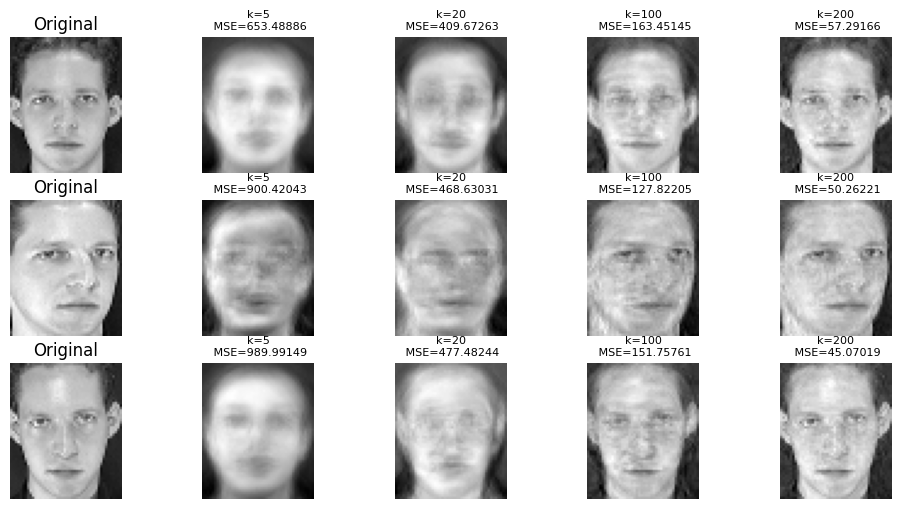

In [13]:
def get_top_k_eigenpairs(sorted_eigenvalues, sorted_eigenvectors,k):
  # TODO: function that returns the top k eigenvectors and corresponding eigenvalues
  return sorted_eigenvalues[:k], sorted_eigenvectors[:, :k]

img_idxs = [0, 1, 2]
ks = [5, 20 ,100, 200]

n_row = len(img_idxs)
n_col = 1 + len(ks)

f, axarr = plt.subplots(n_row, n_col, figsize=(12, 6))

for i in range(n_row):
    img_idx = img_idxs[i]
    axarr[i][0].imshow(x_train[img_idx].reshape((56,46)), cmap='gray')
    axarr[i][0].set_title('Original')
    axarr[i][0].axis('off')

    for j, k in enumerate(ks):

        top_k_eigenvalues, top_k_eigenvectors = get_top_k_eigenpairs(sorted_eigenvalues, sorted_eigenvectors, k)

        # TODO
        x_reconstruct = reconstruct(x_train[img_idx], top_k_eigenvectors, x_mean)
        # TODO

        # TODO
        mse = np.mean((x_reconstruct - x_train[img_idx]) ** 2)

        # TODO

        axarr[i][j+1].imshow(x_reconstruct.reshape((56,46)), cmap='gray')
        axarr[i][j+1].set_title('k={}\n MSE={:.5f}'.format(k, mse), fontsize=8)
        axarr[i][j+1].axis('off')

1-(e). [3pts] Using $k=40$ and $k=250$, reproject X\_train and X\_test into PCA space. Visualize the 10 closest training faces (Euclidean distance) to the first 5 test faces. Report top-1, top-5, and top-10 accuracy for both k values.

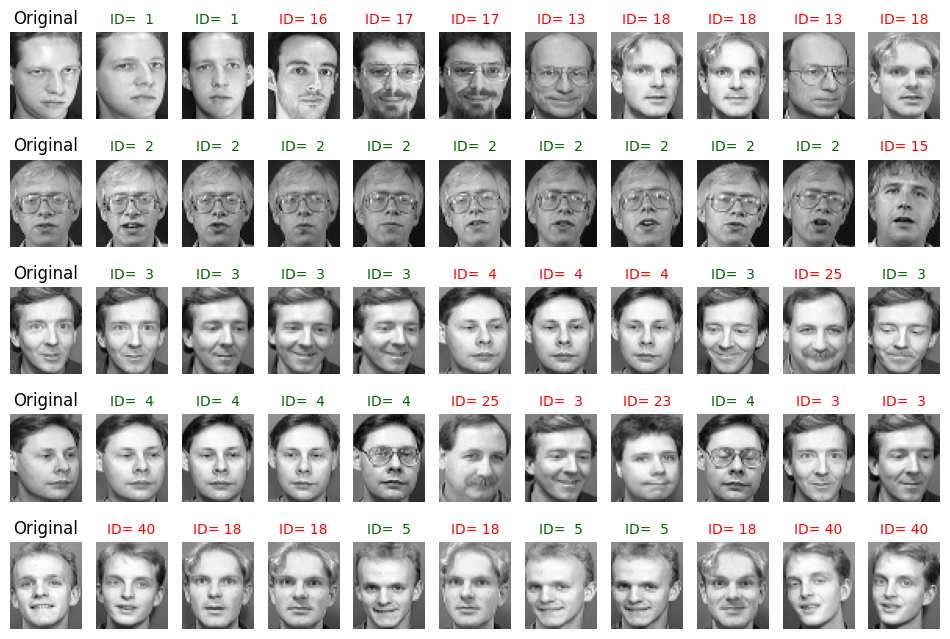

In [14]:
def euclidean(point, data):
    return np.sqrt(np.sum((point - data)**2))

f, axarr = plt.subplots(5,11, figsize=(12, 8))

# TODO
k = 250
x_train_reduced = reproject(x_train, top_k_eigenvectors, x_mean)
x_test_reduced = reproject(x_test, top_k_eigenvectors, x_mean)
# TODO

for i in range(5):
    axarr[i,0].imshow(x_test[i].reshape((56,46)), cmap='gray')
    axarr[i,0].set_title('Original')
    axarr[i,0].axis('off')

    face_distance = [euclidean(point, x_test_reduced[i]) for point in x_train_reduced]
    top_k_faces = np.argsort(face_distance, axis=0)[:10]

    for j in range(10):
        axarr[i, j+1].imshow(x_train[top_k_faces[j]].reshape((56,46)), cmap='gray')
        if y_train[top_k_faces[j]] != i+1:
            axarr[i, j+1].set_title('ID={:3d}'.format(int(y_train[top_k_faces[j]][0])), fontsize=10, color='red')
        else:
            axarr[i, j+1].set_title('ID={:3d}'.format(int(y_train[top_k_faces[j]][0])), fontsize=10, color='darkgreen')
        axarr[i, j+1].axis('off')

1-(f). [3pts] Estimate the smallest $n$ where the reconstructed image retains $95\%$ of the original variance, using the CEVR from 1-(b).



In [15]:
# Implement the code and elaborate your answer in the pdf
for n in range(1, len(sorted_eigenvalues)+1):
    if get_CEVR(sorted_eigenvalues, n) >= 0.95:
        print(f"Smallest n for 95% variance: {n}")
        break

Smallest n for 95% variance: 164


**1**-(g). [2pts] Compute PCA’s computational complexity (the big $O-$notation) for eigen-decomposition, with $N$ samples and $d$ features.

In [16]:
# Elaborate your answer in the pdf

1-(h). [2pts] Describe a computer vision application (e.g., face recognition) using PCA, and explain how k affects its performance.

In [17]:
# Elaborate your answer in the pdf

# Problem 2: k-Means Clustering (25\%)

### Introduction

K-means is a popular clustering algorithm in machine learning used to partition a dataset into K distinct, non-overlapping subsets (or clusters). The goal of K-means is to minimize the within-cluster variances, meaning it tries to make the intra-cluster points as similar as possible while keeping the clusters as distinct as possible.

### Dataset

The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning.

- `mnist\_train.csv`: the first column contains the image label and the remaining columns contain the pixel value with 60,000 training data.
- `mnist\_test.csv`: the first column contains the image label and the remaining columns contain the pixel value with 10,000 testing data.


In [18]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

mnist_train = pd.read_csv(folder_path + "data/p2/mnist_train.csv")
mnist_test = pd.read_csv(folder_path + "data/p2/mnist_test.csv")

print(f'Shape of mnist_train: {mnist_train.shape}')
print(f'Shape of mnist_test: {mnist_test.shape}')

mnist_train.head(5)

Shape of mnist_train: (60000, 785)
Shape of mnist_test: (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The first column in the dataset serves as the labels, this column contains integers from 0 to 9, each representing one of the ten handwritten digits in the MNIST dataset. The remaining columns are the feature columns that constitute the image data. Each image in the MNIST dataset is 28x28 pixels, and these pixels are flattened into a 1D array of 784 pixels (28x28=784) for each row.

In [19]:
train_x = mnist_train.drop(['label'], axis=1).to_numpy()
train_y = mnist_train['label'].to_numpy()
test_x = mnist_test.drop(['label'], axis=1).to_numpy()
test_y = mnist_test['label'].to_numpy()

print('Shape of train_x: ', train_x.shape)
print('Shape of train_y: ', train_y.shape)
print('Shape of test_x: ', test_x.shape)
print('Shape of test_y: ', test_y.shape)

Shape of train_x:  (60000, 784)
Shape of train_y:  (60000,)
Shape of test_x:  (10000, 784)
Shape of test_y:  (10000,)


First use PCA in part 1 to reduce the dimension of each data to **2 dimensions** instead of directly computing the K-means clustering on 784 dimensions.

In [20]:
stacked_x = np.vstack((train_x, test_x))

mean_x, covariance_matrix, sorted_eigenvalues, sorted_eigenvectors = my_pca(stacked_x)
top_k_eigenvectors = sorted_eigenvectors[:,:2]

reprojected_train_x = reproject(train_x, top_k_eigenvectors, mean_x)
reprojected_test_x = reproject(test_x, top_k_eigenvectors, mean_x)

x_mean Shape: (784,)
Covariance Matrix Shape: (784, 784)
Eigenvalues Shape: (784,)
Eigenvectors Shape: (784, 784)


### K-Means Clustering

2-(a). [5pts] Implement the k-Means clustering algorithm by the following steps using Python:


1. (Initialization) Choose the number of clusters $k$ and randomly initialize $k$ centroids using Farthest Point Sampling (FPS) taught in lecture.
2. (Assignment) Assign each data point to the nearest cluster centroids.
3. (Update) Update each cluster centroid as the mean of all the data points assigned to it.
4. (Repeat) Repeat Steps 2 \& 3 until no more data points are being reassigned.
\end{enumerate}


 (Hint: First use PCA in p1 to reduce the dimension of each data to \textcolor{red}{$2$-dim} instead of directly computing the k-means clustering on $784$-dim.)

In [21]:
def euclidean(point, data):
    return np.sqrt(np.sum((point - data)**2, axis=1))

class MyKMeans:
    def __init__(self, n_clusters=10, max_iter=40, verbose=False):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.current_iter = 0
        self.centroids = []
        self.verbose = verbose

    def fit(self, train_x):
        # 1. Initialization: pick first centroid randomly
        centroid_idx = np.random.randint(0, train_x.shape[0])
        self.centroids.append(train_x[centroid_idx])

        # FPS: pick remaining centroids as farthest points
        for _ in range(self.n_clusters - 1):
            distances = np.array([min(euclidean(x, np.array(self.centroids))) for x in train_x])
            self.centroids.append(train_x[np.argmax(distances)])

        self.centroids = np.array(self.centroids)
        assert len(self.centroids) == self.n_clusters

        # show initial state
        initial_sorted = [[] for _ in range(self.n_clusters)]
        for idx, x in enumerate(train_x):
            dists = euclidean(x, self.centroids)
            initial_sorted[np.argmin(dists)].append(x)
        if self.verbose:
            self.visualize(initial_sorted)

        prev_centroids = None
        while not np.array_equal(self.centroids, prev_centroids) and self.current_iter < self.max_iter:
            # 2. Assignment
            sorted_points = [[] for _ in range(self.n_clusters)]
            sorted_indices = [[] for _ in range(self.n_clusters)]
            for idx, x in enumerate(train_x):
                dists = euclidean(x, self.centroids)
                centroid_idx = np.argmin(dists)
                sorted_points[centroid_idx].append(x)
                sorted_indices[centroid_idx].append(idx)

            # only show first iteration
            if self.verbose and self.current_iter == 0:
                self.visualize(sorted_points)

            # 3. Update
            prev_centroids = np.copy(self.centroids)
            for i, cluster in enumerate(sorted_points):
                if cluster:
                    self.centroids[i] = np.mean(cluster, axis=0)

            self.current_iter += 1

        # show final state
        if self.verbose:
            self.visualize(sorted_points)

        self.sorted_indices = sorted_indices
        return sorted_points

    def visualize(self, sorted_points):
        plt.figure(figsize=(5, 3))
        plt.title(f'K-Means Clustering Iteration: {self.current_iter}')
        colors = [plt.cm.tab10(i) for i in range(self.n_clusters)]
        for i, cluster in enumerate(sorted_points):
            if cluster:
                cluster = np.array(cluster)
                plt.scatter(cluster[:, 0], cluster[:, 1], s=10, color=colors[i])
                plt.scatter(self.centroids[i][0], self.centroids[i][1], s=100, color=colors[i], marker='x')
        plt.show()

    def evaluate(self, sorted_points, train_x, train_y):
        point_cluster_labels = []
        for i in range(self.n_clusters):
            indices = self.sorted_indices[i]
            if indices:
                cluster_labels = train_y[indices]
                most_common = np.bincount(cluster_labels).argmax()
                point_cluster_labels.append(most_common)
            else:
                point_cluster_labels.append(-1)
        return point_cluster_labels

    def predict(self, test_x, sorted_points, train_x, train_y):
        cluster_labels = self.evaluate(sorted_points, train_x, train_y)
        data_labels = []
        for point in test_x:
            nearest_cluster = np.argmin(euclidean(point, self.centroids))
            data_labels.append(cluster_labels[nearest_cluster])
        return None, data_labels

2-(b). [4pts] Visualize the initial, first, and final step of the $k$-means clustering for the first 200 data points, with $k=10$ on a 2D plot. Ensure that each data point and its corresponding centroid are assigned a unique color in the visualization.

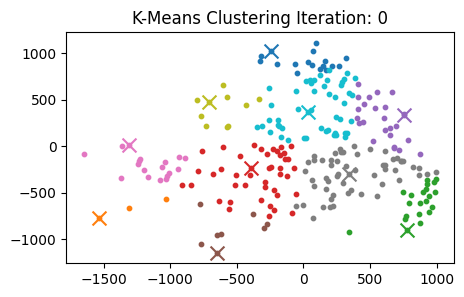

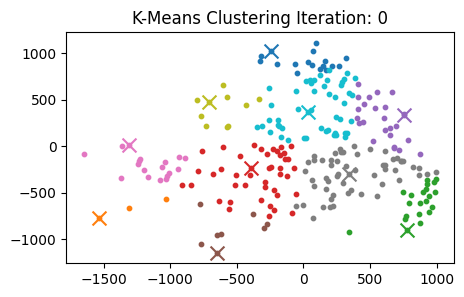

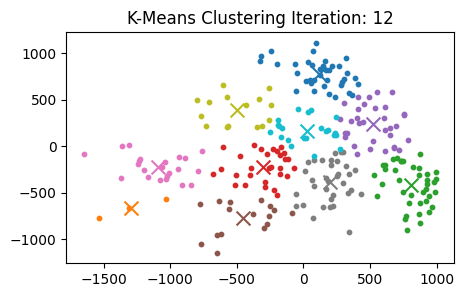

In [22]:
my_kmeans = MyKMeans(n_clusters=10, verbose=True)
sorted_points = my_kmeans.fit(reprojected_train_x[:250])

2-(c). [4pts] For each cluster formed by the k-means algorithm, identify the label that occurs most frequently within that cluster, based on the training data labels. This label will be considered the representative label for the entire cluster. Then, using these representative labels, predict the labels for the test dataset (\texttt{mnist\_test.csv}) which contains 10,000 samples. Finally, compare these predicted labels against the actual labels in the test dataset to evaluate the classification accuracy of the k-means clustering model.

In [23]:
my_kmeans = MyKMeans(n_clusters=10, verbose=False)
sorted_points = my_kmeans.fit(reprojected_train_x)

_, predicted_labels = my_kmeans.predict(reprojected_test_x, sorted_points, reprojected_train_x, train_y)

accuracy = np.mean(np.array(predicted_labels) == test_y)
print(f"Test accuracy (k=10): {accuracy:.4f}")

Test accuracy (k=10): 0.4176


2-(d). [4pts] Experiment with different numbers of clusters, specifically $k=5$, $10$, $20$, and $40$. Report the classification accuracy for each and provide your observations based on the results.

In [24]:
# TODO
# Repeat what you did in 2-(c) but with different cluster numbers
for k in [5, 10, 20, 40]:
    my_kmeans = MyKMeans(n_clusters=k, verbose=False)
    sorted_points = my_kmeans.fit(reprojected_train_x)
    _, predicted_labels = my_kmeans.predict(reprojected_test_x, sorted_points, reprojected_train_x, train_y)
    accuracy = np.mean(np.array(predicted_labels) == test_y)
    print(f"k={k}: Test accuracy = {accuracy:.4f}")
# TODO

k=5: Test accuracy = 0.3742
k=10: Test accuracy = 0.4201
k=20: Test accuracy = 0.4394
k=40: Test accuracy = 0.4523


2-(e). [4pts] Implement GMM clustering algorithm using the sci-kit-learn package on the training data and then report the classification accuracy of the testing data.

In [35]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Fit GMM on the training data (same 2D PCA features)
n_components = 40  # you can also try 10 to compare with k-means
gm = GaussianMixture(n_components=n_components, random_state=0)
gm.fit(reprojected_train_x)

# Component assignments for train and test
train_components = gm.predict(reprojected_train_x)
test_components  = gm.predict(reprojected_test_x)

# Map each component to a digit label by majority vote over train set
component_labels = np.full(n_components, -1, dtype=int)
for c in range(n_components):
    idx = np.where(train_components == c)[0]
    if len(idx) == 0:
        continue
    labels_c = train_y[idx]
    component_labels[c] = np.bincount(labels_c).argmax()

# Predicted labels for test data
predicted_labels = component_labels[test_components]

# Compute classification accuracy
gmm_accuracy = np.mean(predicted_labels == test_y)
print(f"GMM test accuracy (n_components={n_components}): {gmm_accuracy:.4f}")

GMM test accuracy (n_components=40): 0.4533


2-(f). [2pts] Can you think of a situation where using Farthest Point Sampling (FPS) would fail in the case of the MNIST dataset? Discuss the potential limitations or challenges of applying FPS to this particular dataset and how it might affect the clustering outcomes.

In [26]:
# Elaborate your answer in the pdf

2-(g). [2pts] Based on your result in 2-(c), do the centroids obtained from k-means clustering each correspond to distinct labels, such as the digits 0 through 9 in the MNIST dataset? If not, explain why.

In [27]:
# Implement the code and elaborate your answer in the pdf

# Problem 3: EM Algorithm (10\%)

For 3-(a) and 3-(b), please show your calculation steps and the final answer in the pdf

#  🏠 Problem 4: Linear Regression

Our objective is to apply multivariate linear regression so as to predict the price of any house in that area, given a number of its features (e.g. number of bathrooms, year in which the house was built, etc.).

## Dataset

King County House Sales Dataset contains house sale prices for King County, which includes Seattle, between May 2014 and May 2015. There are 3 files that you can directly download from `hw1/ee443_hw1_p4.ipynb`:

- `hw1_p4_train_data.csv`: consists of a total of 20,000 lines containing 21 columns of features.
- `hw1_p4_test_data.csv`: consists of a total of 1,613 lines containing 21 columns of features.
- `hw1_p4_column_definitions.txt`: consists of the rough definitions for each of the column names.

In [28]:
import pandas as pd
import seaborn as sns
import sklearn as sk
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split


### 4-(a). [5pts] Follow the instructions in starter code ee443_hw1.ipynb and finished the implementations of linear regression using scikit-learn using only "sqft_living" and "bedrooms" as features. Report the validation and testing error (mean-square-error) and $R^2$ in your pdf.

In [29]:
# Option 1: Download the data using gdown
!gdown --fuzzy https://drive.google.com/file/d/1a--UvufKpP5yncCH8NFphrZVM_BlYI-B/view?usp=share_link --output hw1_p4_train_data.csv
!gdown --fuzzy https://drive.google.com/file/d/1wy5gzjymhX79lEK_mUPWBDUgGjtqp85d/view?usp=share_link --output hw1_p4_test_data.csv
!gdown --fuzzy https://drive.google.com/file/d/1oqCAnRYIS_GR2c44xIj1v_o2QPA3ax2N/view?usp=share_link --output hw1_p4_column_definitions.txt

# Option 2: Or do the mounting presented in the last assignment

# Option 3: Or directly drag the files into this runtime

Downloading...
From: https://drive.google.com/uc?id=1a--UvufKpP5yncCH8NFphrZVM_BlYI-B
To: /content/hw1_p4_train_data.csv
100% 2.25M/2.25M [00:00<00:00, 179MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wy5gzjymhX79lEK_mUPWBDUgGjtqp85d
To: /content/hw1_p4_test_data.csv
100% 182k/182k [00:00<00:00, 98.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1oqCAnRYIS_GR2c44xIj1v_o2QPA3ax2N
To: /content/hw1_p4_column_definitions.txt
100% 1.33k/1.33k [00:00<00:00, 5.00MB/s]


In [30]:
train_data = pd.read_csv("hw1_p4_train_data.csv")
test_data = pd.read_csv("hw1_p4_test_data.csv")
train_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,424500100,20141008T000000,189900.0,2,1.0,800,5600,1.0,0,0,...,6,800,0,1955,0,98056,47.4959,-122.172,1100,6000
1,3630020090,20150504T000000,454280.0,3,2.5,1470,1741,2.0,0,0,...,8,1170,300,2004,0,98029,47.5464,-121.999,1470,1583
2,3488300085,20140919T000000,435000.0,2,1.0,720,5600,1.0,0,0,...,7,720,0,1920,0,98116,47.5641,-122.391,1330,5600
3,4051100390,20150508T000000,240000.0,3,1.0,1310,7125,1.0,0,0,...,7,1310,0,1978,0,98042,47.3739,-122.148,1650,7290
4,5693501028,20150403T000000,610000.0,3,2.5,1300,1331,3.0,0,0,...,8,1300,0,2007,0,98103,47.6607,-122.352,1450,5270


In [31]:
list(train_data.columns)

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [32]:
# we need to do some data preprocessing before fitting a Linear Regression model
# For example, the column "date" is under the format of "YYYYMMDDT000000" (e.g., 20141008T000000)
process_date = lambda x: x.split('T')[0]

train_data["date"] = train_data["date"].apply(process_date)
test_data["date"] = test_data["date"].apply(process_date)

In [37]:
# decide what are the feature and what are the labels
x_train = train_data[['sqft_living', 'bedrooms']]
y_train = train_data[['price']]

x_test = test_data[['sqft_living', 'bedrooms']]
y_test = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

# TODO: Standardize the data using mean and std from the training set:

# use only the two specified features
feature_cols = ["sqft_living", "bedrooms"]

# select the two columns from each split
x_train = x_train[feature_cols]
x_val   = x_val[feature_cols]
x_test  = x_test[feature_cols]

# compute mean and std on training split (per column)
x_mean = x_train.mean(axis=0)
x_std  = x_train.std(axis=0)

# standardize using train statistics
x_train_n = (x_train - x_mean) / x_std
x_val_n   = (x_val   - x_mean) / x_std
x_test_n  = (x_test  - x_mean) / x_std

# TODO ENDS HERE

In [39]:
# Fit linear regression model and calculate the $R^2$ of the model predictions on validation and test splits

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
linear_regression_model = LinearRegression().fit(x_train_n, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val_n, y_val)
test_score = linear_regression_model.score(x_test_n, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.51
testing $R^2$: 0.47


validation MSE: 6.52e+10
testing MSE: 5.82e+10


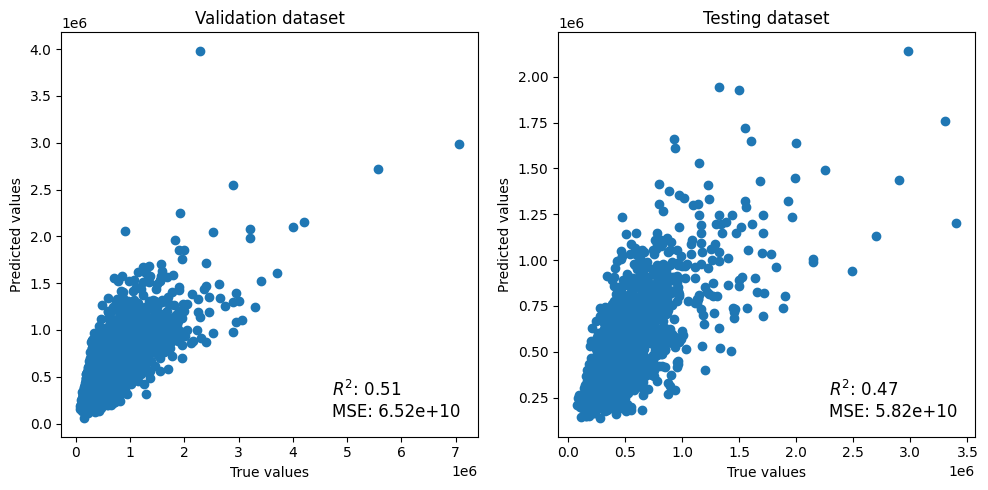

In [40]:
# Additionally, calculate MSE and plot results
from sklearn.metrics import mean_squared_error

# TODO: Calculate Mean-Square-Error for both validation dataset and testing dataset
y_val_pred  = linear_regression_model.predict(x_val_n)
y_test_pred = linear_regression_model.predict(x_test_n)
val_mse  = mean_squared_error(y_val,  y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# TODO ENDS HERE

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

# Run the plotting code below to visualize the results

# Plot 1x2 subplots of predictions vs measurements for the validation and testing datasets

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

### 4-(b). [4pts] Now fit the Linear Regression model using all the features as input, and report the error improvement over 4-(a).

In [48]:
# Now use all the features as input
x_train = train_data.drop(['price', 'date', 'id'], axis=1)
y_train = train_data[['price']]

x_test = test_data.drop(['price', 'date', 'id'], axis=1)
y_test = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

# TODO

# TODO ENDS HERE

linear_regression_model = LinearRegression().fit(x_train, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val, y_val)
test_score = linear_regression_model.score(x_test, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.69
testing $R^2$: 0.71


validation MSE: 4.12e+10
testing MSE: 3.20e+10


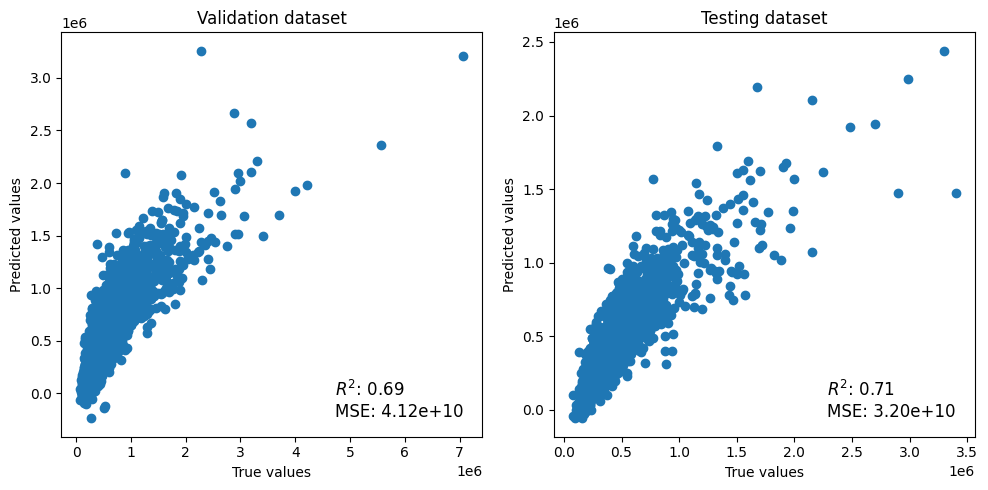

In [49]:
# TODO: Calculate Mean-Square-Error for both validation dataset and testing dataset
y_val_pred  = linear_regression_model.predict(x_val)
y_test_pred = linear_regression_model.predict(x_test)
val_mse  = mean_squared_error(y_val,  y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
# TODO ENDS HERE

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

# Run the plotting code below to visualize the results

# Plot 1x2 subplots of predictions vs measurements for the validation and testing datasets

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

In [50]:
# TODO: calculate change in both MSE and R^2 between the model with only 'sqft_living' and 'bedrooms' and the model with all features

mse_change = test_mse_a - test_mse    # >0 means all-features model reduced MSE
r2_change  = test_score - test_score_a

print(f"MSE change: {mse_change:.2e}")
print(f"R^2 change: {r2_change:.2f}")

MSE change: 0.00e+00
R^2 change: 0.00


### 4-(c). [4pts] Now select 8 features that have the largest absoulute coefficient and use them to fit the Linear Regression model, report the columns you selected, error improvement over 4-(a) and 4-(b) (if any), and possible reasoning.

In [51]:
# the coef_ represents the coefficients for the linear regression problem
# the intercept_ represents the independent term in the linear model.
print(linear_regression_model.coef_)
print(linear_regression_model.intercept_) # not necessary for the homework but showing for completion

[[-3.63549786e+04  4.32863746e+04  1.12194483e+02  1.20783271e-01
   6.79913124e+03  5.64836702e+05  5.84143572e+04  2.50345141e+04
   9.42692421e+04  7.24136238e+01  3.97808583e+01 -2.68094410e+03
   1.59920427e+01 -6.05861638e+02  6.16215875e+05 -2.12380088e+05
   2.03109139e+01 -3.47161865e-01]]
[8766357.43163074]


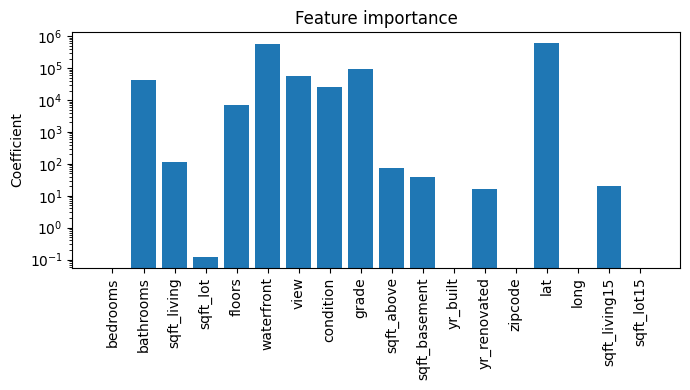

In [52]:
# TODO: plot features vs coefficient sorted by descending coefficient

features = x_train.columns
coefs = linear_regression_model.coef_.ravel()

# DON'T FORGET TO SORT THE FEATURES AND COEFFICIENTS BY DESCENDING WEIGHT BEFORE PLOTTING!

# TODO ENDS HERE

# bar plot of the coefficients - note this will plot using logscale on y-axis due to high feature weights
plt.figure(figsize=(7, 4))
plt.bar(features, coefs,log=True)
plt.xticks(rotation=90)
plt.ylabel("Coefficient")
plt.title("Feature importance")
plt.tight_layout()

In [54]:
selected_features = features[:8]
# TODO: Fit linear regression using selected subset of features
x_train = train_data[selected_features]
y_train = train_data[['price']]

x_test  = test_data[selected_features]
y_test = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=0)

# TODO: Normalize the data: x_train, x_val, y_train, y_val, x_test, y_test

# TODO ENDS HERE

linear_regression_model = LinearRegression().fit(x_train_n, y_train)

# calculate the $R^2$ of the model predictions
val_score = linear_regression_model.score(x_val_n, y_val)
test_score = linear_regression_model.score(x_test_n, y_test)

print(f"validation $R^2$: {val_score:.2f}")
print(f"testing $R^2$: {test_score:.2f}")

validation $R^2$: 0.51
testing $R^2$: 0.47


validation MSE: 6.52e+10
testing MSE: 5.82e+10


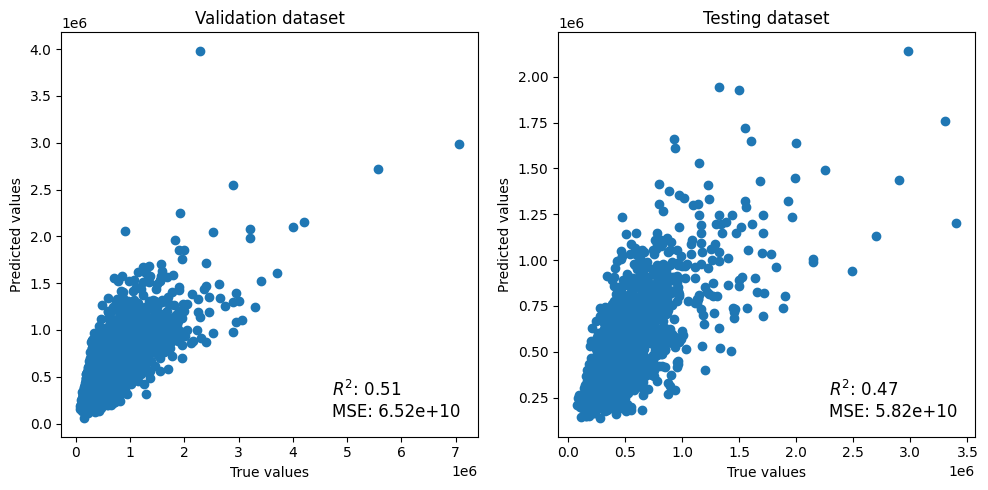

In [55]:
# TODO: Calculate Mean-Square-Error for both validation dataset and testing dataset
y_val_pred  = linear_regression_model.predict(x_val_n)
y_test_pred = linear_regression_model.predict(x_test_n)
val_mse  = mean_squared_error(y_val,  y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# TODO ENDS HERE

print("validation MSE: {:.2e}".format(val_mse))
print("testing MSE: {:.2e}".format(test_mse))

# Run the plotting code below to visualize the results

# Plot 1x2 subplots of predictions vs measurements for the validation and testing datasets

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(y_val, y_val_pred)
axs[0].set_title("Validation dataset")
axs[0].set_xlabel("True values")
axs[0].set_ylabel("Predicted values")
axs[0].text(0.65, 0.05, f"$R^2$: {val_score:.2f}\nMSE: {val_mse:.2e}", transform=axs[0].transAxes, fontsize=12)

axs[1].scatter(y_test, y_test_pred)
axs[1].set_title("Testing dataset")
axs[1].set_xlabel("True values")
axs[1].set_ylabel("Predicted values")
axs[1].text(0.65, 0.05, f"$R^2$: {test_score:.2f}\nMSE: {test_mse:.2e}", transform=axs[1].transAxes, fontsize=12)

plt.tight_layout()

In [57]:
# after finishing 4-(b) MSE and R^2
val_mse_b   = val_mse
test_mse_b  = test_mse
val_score_b = val_score
test_score_b = test_score

In [58]:
# TODO: calculate change in both MSE and R^2 between the model with all features and the model with 8 selected features

mse_change = test_mse_b - test_mse    # >0 means 8-feature model reduced MSE
r2_change  = test_score - test_score_b

print(f"MSE change: {mse_change:.2e}")
print(f"R^2 change: {r2_change:.2f}")

MSE change: 0.00e+00
R^2 change: 0.00


### 4-(d). [4pts] Redo 1-(b), this time normalizing the y-variable ('price') prior to fitting. Does prediction performance change? Also, visualize feature weights sorted in descending order of absolute value (do not use log-scale this time). Are the top 8 features the same as when the y-variable is not normalized? Provide your answers to these questions in the PDF.

validation R^2 (normalized y): 0.69
testing R^2 (normalized y): 0.71
validation MSE (normalized y): 2.99e-01
testing MSE (normalized y): 2.32e-01


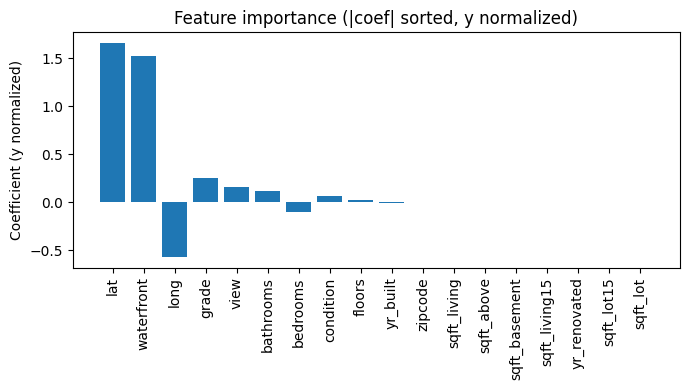

Top 8 features with normalized y: ['lat', 'waterfront', 'long', 'grade', 'view', 'bathrooms', 'bedrooms', 'condition']


In [59]:
# 4-(d): redo 4-(b) but normalize y ('price')

# Use the same all-feature matrices as in 4-(b)
x_train = train_data.drop(['price', 'date', 'id'], axis=1)
y_train = train_data[['price']]
x_test  = test_data.drop(['price', 'date', 'id'], axis=1)
y_test  = test_data[['price']]

# create a validation set
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.25, random_state=0
)

# ---- normalize y only ----
y_mean = y_train.mean(axis=0)
y_std  = y_train.std(axis=0)

y_train_n = (y_train - y_mean) / y_std
y_val_n   = (y_val   - y_mean) / y_std
y_test_n  = (y_test  - y_mean) / y_std

# fit linear regression on x (raw) and normalized y
linear_regression_model = LinearRegression().fit(x_train, y_train_n)

# R^2 using normalized targets
val_score_n = linear_regression_model.score(x_val, y_val_n)
test_score_n = linear_regression_model.score(x_test, y_test_n)
print(f"validation R^2 (normalized y): {val_score_n:.2f}")
print(f"testing R^2 (normalized y): {test_score_n:.2f}")

# MSE in normalized-y space
from sklearn.metrics import mean_squared_error
y_val_pred_n  = linear_regression_model.predict(x_val)
y_test_pred_n = linear_regression_model.predict(x_test)

val_mse_n  = mean_squared_error(y_val_n,  y_val_pred_n)
test_mse_n = mean_squared_error(y_test_n, y_test_pred_n)
print("validation MSE (normalized y): {:.2e}".format(val_mse_n))
print("testing MSE (normalized y): {:.2e}".format(test_mse_n))

# ---- coefficient plot without log scale, sorted by |coef| ----
features = x_train.columns
coefs = linear_regression_model.coef_.ravel()

sorted_idx = np.argsort(np.abs(coefs))[::-1]
features_sorted = features[sorted_idx]
coefs_sorted = coefs[sorted_idx]

plt.figure(figsize=(7, 4))
plt.bar(features_sorted, coefs_sorted)  # no log=True
plt.xticks(rotation=90)
plt.ylabel("Coefficient (y normalized)")
plt.title("Feature importance (|coef| sorted, y normalized)")
plt.tight_layout()
plt.show()

# top-8 feature names (for your PDF answer)
top8_features_normy = list(features_sorted[:8])
print("Top 8 features with normalized y:", top8_features_normy)

### 4-(e). [4pts] Plot the correlation matrix using the provided function. Turn in the correlation matrix plot and reported your observation.

In [60]:
!pip install matplotlib --upgrade # make sure your matplotlib version is the latest

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 7.0 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [61]:
import matplotlib.pyplot as plt # plotting

def plotCorrelationMatrix(df, graphWidth=10):
    df = df.dropna(axis='columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.show()

<Figure size 800x800 with 0 Axes>

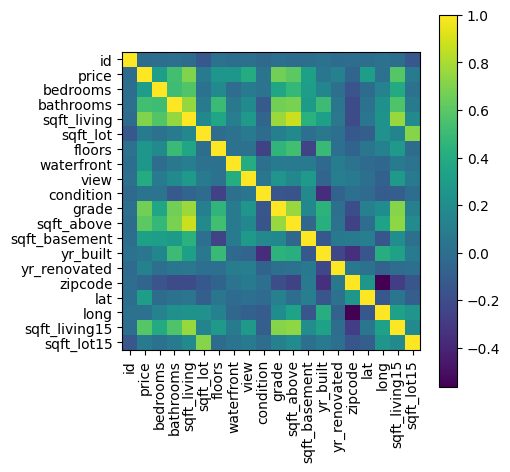

In [63]:
import matplotlib.pyplot as plt # plotting
import pandas as pd
import numpy as np

def plotCorrelationMatrix(df, graphWidth=10):
    # Select only numeric columns for correlation calculation
    numeric_df = df.select_dtypes(include=np.number)

    # Drop columns with NaN (if any remain after selecting numeric)
    numeric_df = numeric_df.dropna(axis='columns')

    # Keep columns where there are more than 1 unique values
    df_filtered = numeric_df[[col for col in numeric_df if numeric_df[col].nunique() > 1]]

    if df_filtered.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant numeric columns ({df_filtered.shape[1]}) is less than 2')
        return

    corr = df_filtered.corr()

    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    # Removed the deprecated 'fignum' argument from plt.matshow
    corrMat = plt.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.show()

# Now call the corrected function
plotCorrelationMatrix(train_data)

For 4-(f,g,h), you are aksed to derive the close-form solution of linear regression, please refers to the handout and answer them on the pdf.

## 5. [5pts] Support Vector Machine (10%).

For 5-(a)~(c)~, please show your calculation steps and the final answer in the pdf